## Optical signal propagation during an earthquake
The other demos demonstrate signal transmission and propagation, and earthquake modelling.
This notebook brings those two together, modelling the propagation of a signal during an earthquake.

We start by defining the system parameters as usual.

In [4]:
from configparser import ConfigParser

parameters = ConfigParser()

parameters['FIBRE'] = {
    'section_length':    '1000',  # Correlation length in m
    'path_coordinates': '[ \
        [-73.10897397357299,-36.83168432227461], \
        [-73.12487396171335,-35.95811819864919], \
        [-72.8998741217013,-35.47096027456558], \
        [-72.41606446443656,-35.3183747616349], \
        [-72.44987444048532,-34.73466151270862], \
        [-72.22487459987728,-33.991743556435], \
        [-71.60009504247698,-33.54688527485856] \
    ]',                          # Estimate coordinates of the Prat cable, taken from https://www.submarinecablemap.com/api/v3/cable/cable-geo.json
    'PMD_parameter':     '0.1',  # Polarisation mode dispersion parameter in ps / (km ^ 0.5)
    'realisation_count': '1000', # Number of fibre realisations to simulate simultaneously
    'photoelasticity':   '0.78', # Photoelasticity, which relates material strain to optical strain
}

parameters['TRANSCEIVER'] = {
    'constellation':    'QPSK',  # The symbol constellation to use
    'power':            '2',     # Transmission power in dBm
    'baud_rate':        '1e11',  # Baud rate in symbols / s
    'pulse':            'RRCOS', # Pulseshape, can be SINC or RRCOS, or define your own using the Pulse class
    'pulse_parameter':  '0.5',   # Parameter to pass to the pulse constructor. For a RRCOS pulse, this is the rolloff factor
    'upsample_factor':  '4',     # Samples per symbol
    'filter':           'RRCOS', # Antialiasing (matched) filter
    'filter_parameter': '0.5'    # Same
}

parameters['SIGNAL'] = {
    'batch_size':   '1',  # The number of signals to transmit simultaneously
    'symbol_count': '25', # The number of symbols to transmit per signal
    'carrier': '1550'     # Signal carrier wavelength in nm
}

parameters['EARTHQUAKE'] = {
    'event': 'GCMT:C201002270634A', # A historic earthquake event, structured <catalog>:<identifier> (e.g. from https://www.globalcmt.org/)
    'model': 'ak135f_5s'            # Earth model for Syngine to use from https://ds.iris.edu/ds/products/syngine/#earth
}

Now, we create the transceiver, fibre and earthquake.

In [5]:
from tremor_waveplate_toolbox import Transmitter, Fibre, Receiver, Earthquake

transmitter = Transmitter(parameters)
fibre = Fibre(parameters)
receiver = Receiver(parameters)
earthquake = Earthquake(parameters)

Next, we obtain the strain imposed on the fibre by the earthquake over time

In [6]:
_, _, _, strain = earthquake(fibre, verbose = True)

Requesting seismograms from Syngine at 429 coordinates along the fibre. This may take a while..
Syngine request complete. Collecting and validating results..
Results validated and returned!


We specify the moment at which transmission begins, relative to the start of the earthquake measurement.
As strain changes slowly with respect to the optical sample rate, we assume strain to be constant from this moment until the transmission end.
Signal time is corrected for the mean group delay, so we have to transform the time axis to obtain the correct corresponding strain.

In [7]:
import numpy as np

transmission_time       = 360 # Start transmission one minute after the earthquake
earthquake_sample_index = np.searchsorted(strain.time, transmission_time) # Assume constant strain during signal transmission
sampled_strain          = strain.samples_time[:, earthquake_sample_index, 0]  # Strain during transmission

Now, let's apply this strain to the fibre and compare signal propagation to the strainless case.

In [8]:
_, pilot_signal = transmitter.transmit_random(1, parameters.getint('SIGNAL', 'symbol_count'), parameters.getfloat('SIGNAL', 'carrier'))
fibre.section_material_strain = np.zeros_like(fibre.section_material_strain)
received_signal = fibre(pilot_signal)

fibre.section_material_strain = sampled_strain
received_signal_strain = fibre(pilot_signal)

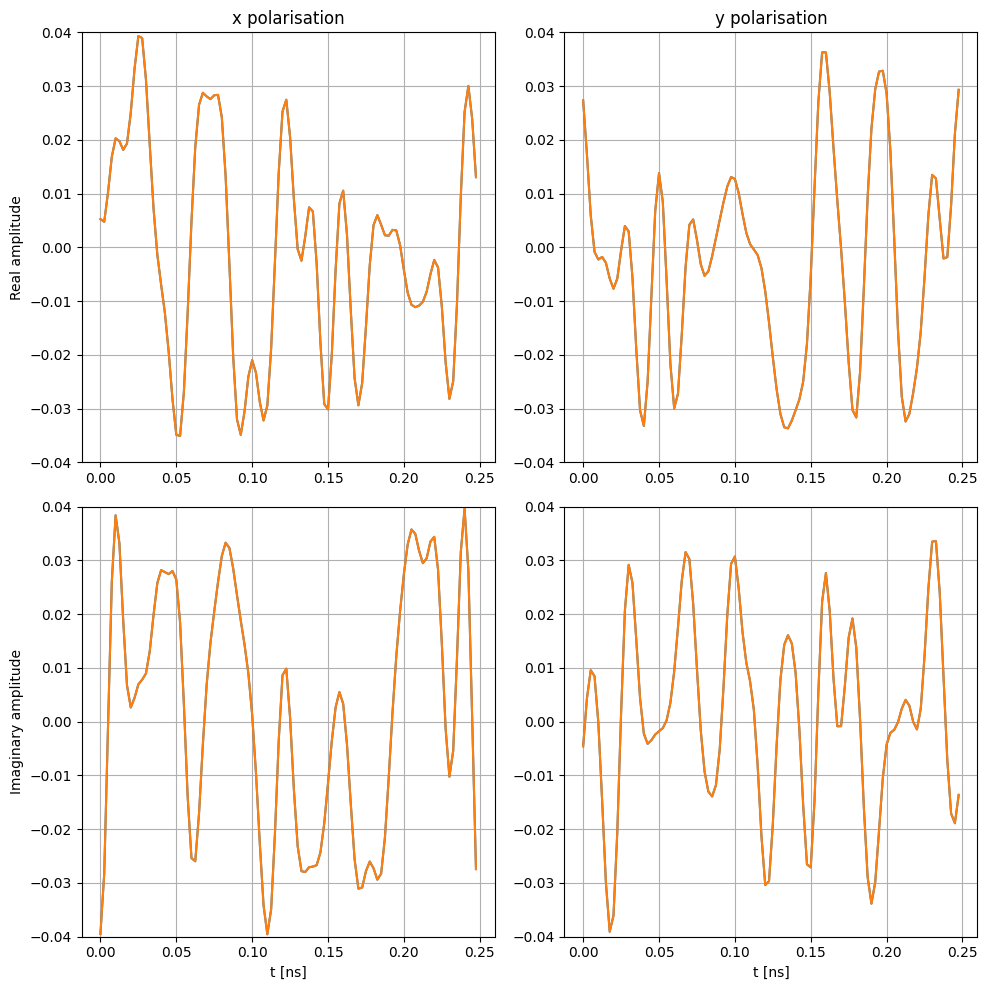

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize = (10, 10))

axes[0, 0].set_title("x polarisation")
axes[0, 0].set_ylabel("Real amplitude")
axes[0, 0].set_ylim([-0.04, 0.04])
axes[0, 0].grid()
axes[0, 0].plot(received_signal.time * 1e9, received_signal.samples_time[0, 0, :, 0].real)
axes[0, 0].plot(received_signal_strain.time * 1e9, received_signal_strain.samples_time[0, 0, :, 0].real)

axes[1, 0].set_xlabel("t [ns]")
axes[1, 0].set_ylabel("Imaginary amplitude")
axes[1, 0].set_ylim([-0.04, 0.04])
axes[1, 0].grid()
axes[1, 0].plot(received_signal.time * 1e9, received_signal.samples_time[0, 0, :, 0].imag)
axes[1, 0].plot(received_signal_strain.time * 1e9, received_signal_strain.samples_time[0, 0, :, 0].imag)

axes[0, 1].set_title("y polarisation")
axes[0, 1].set_ylim([-0.04, 0.04])
axes[0, 1].grid()
axes[0, 1].plot(received_signal.time * 1e9, received_signal.samples_time[0, 0, :, 1].real)
axes[0, 1].plot(received_signal_strain.time * 1e9, received_signal_strain.samples_time[0, 0, :, 1].real)

axes[1, 1].set_xlabel("t [ns]")
axes[1, 1].set_ylim([-0.04, 0.04])
axes[1, 1].grid()
axes[1, 1].plot(received_signal.time * 1e9, received_signal.samples_time[0, 0, :, 1].imag)
axes[1, 1].plot(received_signal_strain.time * 1e9, received_signal_strain.samples_time[0, 0, :, 1].imag)

fig.tight_layout()

plt.show()

In [10]:
print(received_signal.samples_time - received_signal_strain.samples_time)

[[[[-2.36869137e-06+2.02508465e-06j -2.79726302e-07+2.92015494e-07j]
   [-1.19549971e-06+3.22384248e-06j -4.56461369e-06+4.41225409e-07j]
   [ 8.86814393e-07+2.53136198e-06j -6.32508296e-06+2.14699086e-07j]
   ...
   [ 1.29318470e-06-3.99295286e-06j  5.38490699e-06-3.16846644e-07j]
   [ 7.53466390e-08-3.30175235e-06j  6.55673406e-06-6.51874063e-07j]
   [-1.70038625e-06-7.03036731e-07j  4.26886820e-06-2.29979063e-07j]]]


 [[[ 3.12837653e-07-5.75385671e-09j -3.33860478e-07-3.31138275e-07j]
   [-2.25131305e-07-2.53231746e-06j -7.47906460e-07+7.75322456e-08j]
   [-5.67954722e-07-3.51782652e-06j -6.84268502e-07+5.73756407e-07j]
   ...
   [ 2.59877491e-07+2.72230643e-06j  9.75572298e-07+1.18336073e-07j]
   [ 8.00054356e-07+3.71323094e-06j  9.98087804e-07+1.79420136e-08j]
   [ 7.62340701e-07+2.60095245e-06j  4.11277482e-07-2.94920874e-07j]]]


 [[[ 4.23676399e-07-3.74806113e-07j  9.67195444e-07+1.04253525e-07j]
   [-4.96562799e-07+2.02005710e-06j  2.71814032e-07-1.69811719e-06j]
   [-1.12997